# Calcul Matriciel, Optimisation - correction
source : Xavier Dupre 

Calcul matriciel ([numpy](http://www.numpy.org/)).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

## Exercise 1: Chessboard

Create a chessboard matrix (alternating 1s and 0s) of size 8x8, in two different ways
* using slices 
* using the [tile] function (http://docs.scipy.org/doc/numpy/reference/generated/numpy.tile.html#numpy.tile)

In [4]:
import numpy as np
#Exo1a-1:
chess = np.zeros((8,8), dtype=int)
chess[::2,::2] = 1
chess[1::2,1::2] = 1 # Does the same thing

#Exo1a-2:
chess2 = np.tile([[1,0],[0,1]], (4,4))
print(chess2)

[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]


## Exercice 2: 2D extraction trap 
* Define matrix $M = \left(\begin{array}{ccccc} 1 & 5 & 9 & 13 & 17 \\ 2 & 6 & 10 & 14 & 18 \\ 3 & 7 & 11 & 15 & 19 \\ 4 & 8 & 12 & 16 & 20 \\ \end{array}\right)$
* **Extract** the following matrix from it $\left(\begin{array}{ccc} 6 & 18 & 10 \\ 7 & 19 & 11 \\ 5 & 17 & 9 \\ \end{array}\right)$

In [6]:
#Exo1B:
M = np.arange(1, 21).reshape((4,5), order='F')
print(M)

idx_row = [1, 2, 0]
idx_col = [1, 4, 2]
#the following line is wrong: it create couples from the two lists
print("WRONG:\n",M[idx_row, idx_col])
print("-------------")
# first correct way:
print(M[idx_row][:,idx_col])
# we can also use broadcasted indices to create all the couples we want: 
idx = np.ix_(idx_row, idx_col)
print(idx)
print(M[idx])

[[ 1  5  9 13 17]
 [ 2  6 10 14 18]
 [ 3  7 11 15 19]
 [ 4  8 12 16 20]]
WRONG:
 [ 6 19  9]
-------------
[[ 6 18 10]
 [ 7 19 11]
 [ 5 17  9]]
(array([[1],
       [2],
       [0]]), array([[1, 4, 2]]))
[[ 6 18 10]
 [ 7 19 11]
 [ 5 17  9]]


## Exercise 3 : Sieve of Erathosthenes

We wish to implement an [Erathosthenes' sieve](http://fr.wikipedia.org/wiki/Crible_d'%C3%89ratosth%C3%A8ne) to find the prime numbers less than $N=1000$.

* From an array of Booleans of size N+1, all equal to True.
* Set 0 and 1 to False as they are not prime.
* for each integer $k$ between 2 and $\sqrt{N}$: 
    * if $k$ is prime: set its multiples (between $k^2$ and $N$) to False
* print the list of prime integers

In [ ]:
#Exo1c
n = 1001
is_prime = np.ones(n, dtype=bool)
is_prime[:2] = False

for k in range(2, int(np.sqrt(n))+1):
    is_prime[k**2::k] = False # Sets all multiples of k starting from k^2 to False. This marks them as non-prime.
print(np.arange(n)[is_prime])

[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 401 409 419 421 431 433 439 443 449 457 461 463
 467 479 487 491 499 503 509 521 523 541 547 557 563 569 571 577 587 593
 599 601 607 613 617 619 631 641 643 647 653 659 661 673 677 683 691 701
 709 719 727 733 739 743 751 757 761 769 773 787 797 809 811 821 823 827
 829 839 853 857 859 863 877 881 883 887 907 911 919 929 937 941 947 953
 967 971 977 983 991 997]


On remarque que le nombre 6 est barré deux fois car il est multiple de 3 et de 2. Cela signifie que le nombre 6 est barré durant les deux premières itérations. En fait chaque nombre ``k*i`` est nécessaire barré dans une précédente itération si ``i<k``. On remplace donc ``k*i`` par ``k*k`` ou ``k**2``.

In [6]:
#Exo1c
import numpy as np
n = 1001
is_prime = np.ones(n, dtype=bool)
is_prime[:2] = False
for k in range(2, int(np.sqrt(n))):
    is_prime[k*k::k] = False
print(np.arange(n)[is_prime])

[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 401 409 419 421 431 433 439 443 449 457 461 463
 467 479 487 491 499 503 509 521 523 541 547 557 563 569 571 577 587 593
 599 601 607 613 617 619 631 641 643 647 653 659 661 673 677 683 691 701
 709 719 727 733 739 743 751 757 761 769 773 787 797 809 811 821 823 827
 829 839 853 857 859 863 877 881 883 887 907 911 919 929 937 941 947 953
 961 967 971 977 983 991 997]


### Exercice 2 : marches aléatoires

Simulate (**at once!**) 10000 random walks of size 1000, starting from 0 and with +1 or -1 equiprobable steps. 

* Draw a graph representing the root mean square of the positions (=cumulative steps at a given instant) as a function of time.
* What are the maximum and minimum amplitudes reached among all the random steps?
* How many steps are more than 50 away from the origin?
* Of those that do, what is the average passage time (i.e. the first time these steps exceed +/-50)?

You may need the following functions: [np.abs](http://docs.scipy.org/doc/numpy/reference/generated/numpy.absolute.html), [np.mean](http://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html), [np.max](http://docs.scipy.org/doc/numpy/reference/generated/numpy.maximum.html), [np.where](http://docs.scipy.org/doc/numpy/reference/generated/numpy.where.html), [np.argmax](http://docs.scipy.org/doc/numpy/reference/generated/numpy.argmax.html), [np.any](http://docs.scipy.org/doc/numpy/reference/generated/numpy.any.html), [np.cumsum](http://docs.scipy.org/doc/numpy/reference/generated/numpy.cumsum.html), [np.random.randint](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randint.html).

In [7]:
import numpy as np

n_walks = 10000
n_steps = 1000
steps = np.random.randint(0, 2, (n_walks, n_steps))
steps = 2*steps-1 
walks = np.cumsum(steps, axis=1)

# on affiche le premier carré 10x10
walks[:10,:10]

array([[  1,   2,   3,   4,   5,   6,   5,   4,   5,   4],
       [  1,   0,   1,   2,   1,   0,   1,   2,   1,   2],
       [ -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10],
       [  1,   0,   1,   2,   3,   2,   3,   4,   5,   6],
       [ -1,  -2,  -1,   0,  -1,   0,  -1,   0,  -1,  -2],
       [ -1,   0,   1,   2,   3,   4,   3,   4,   3,   2],
       [ -1,   0,   1,   0,   1,   2,   3,   4,   5,   4],
       [ -1,  -2,  -1,   0,   1,   2,   1,   2,   3,   2],
       [  1,   0,  -1,   0,  -1,  -2,  -3,  -4,  -3,  -4],
       [  1,   0,  -1,   0,   1,   2,   1,   2,   3,   4]], dtype=int32)

Highest position:133	Lowest position:-120
Number of walks over bound(=50):2074
Mean crossing time:673.8341369334619


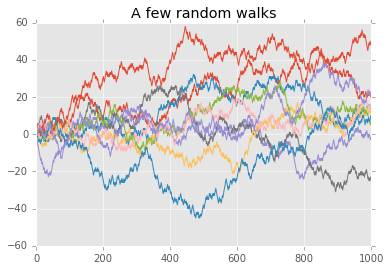

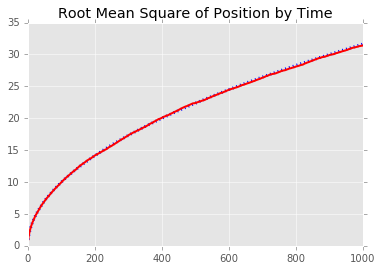

In [8]:
import matplotlib.pyplot as plt
# let's have a quick look at a few random walks
plt.plot(walks[:10,:].transpose())
plt.title('A few random walks')
# Let's see how the root mean square of the position evolves with time/nb of steps
rms_position = np.sqrt( (walks**2).mean(axis=0) )
plt.figure()
t = 1 + np.arange(len(rms_position))
plt.plot(t, np.sqrt(t), ':b', lw=3) #Just to show the fit 
plt.plot(t, rms_position, '-r', lw=2)
plt.title('Root Mean Square of Position by Time')
# What are the highest/lowest positions 
print('Highest position:{max}\tLowest position:{min}'.format(max=walks.max(), min=walks.min()))
# How many walks wander further than 50?
bound = 50
hits_the_bound = np.any(np.abs(walks)> bound, axis=1) #for each walk, do we go further than the bound at any time?
print('Number of walks over bound(={}):{}'.format(bound, hits_the_bound.sum()))
# Among the walks that go beyond the bound, what is the mean of the first hits?
# we use argmax on the boolean array to get the first True value
first_hits = (np.abs(walks[hits_the_bound,:])>bound).argmax(axis=1)
print('Mean crossing time:{}'.format(first_hits.mean()))

## Exercise 5: Find the random series from random walks

The previous exercise shows how to generate a random walk from a random time series. How can we find the initial series from the random walk?

In [9]:
derivee = walks[:,1:] - walks[:,:-1]
derivee[:10,:10]

array([[ 1,  1,  1,  1,  1, -1, -1,  1, -1,  1],
       [-1,  1,  1, -1, -1,  1,  1, -1,  1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1,  1,  1,  1, -1,  1,  1,  1,  1,  1],
       [-1,  1,  1, -1,  1, -1,  1, -1, -1, -1],
       [ 1,  1,  1,  1,  1, -1,  1, -1, -1,  1],
       [ 1,  1, -1,  1,  1,  1,  1,  1, -1,  1],
       [-1,  1,  1,  1,  1, -1,  1,  1, -1, -1],
       [-1, -1,  1, -1, -1, -1, -1,  1, -1,  1],
       [-1, -1,  1,  1,  1, -1,  1,  1,  1,  1]], dtype=int32)

### Exercice 6 : simulation, régression, estimation par maximisation de la vraisemblance

* We begin by simulating the variable $Y = 3 X_1 -2 X_2 +2 + \epsilon$ where $X_1,X_2,\epsilon \sim \mathcal{N}(0,1)$. 
* We then want to find the coefficients in the [linear regression](http://fr.wikipedia.org/wiki/R%C3%A9gression_lin%C3%A9aire) of $Y$ on $X_1$ and $X_2$ in a model with constant, using the Ordinary Least Squares method. Recall that the matrix form of the OLS estimator is $\hat{\beta} = (X'X)^{-1}X'Y$.
* Finally, since $Y$ is normal, we want to estimate its parameters by likelihood maximization:
    * The density is written: $f(x, \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi} } e^{ -\frac{(x-\mu)^2}{2\sigma^2} }$.
    * The log-likelihood: $\ln\mathcal{L}(\mu,\sigma^2) = \sum_{i=1}^n \ln f(x_i;\,\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$.
    * Writing the first-order conditions gives a closed formula for the maximum likelihood estimators: $\hat{\mu} = \overline{x} \equiv \frac{1}{n}\sum_{i=1}^n x_i$, $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \overline{x})^2$.
    * Verify by implementing them directly that you find the same solution as the minimum obtained by using [scipy.optimize.minimize](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) to minimize the opposite of the log-likelihood.


In [ ]:
import numpy as np
import math
from scipy.optimize import minimize
n_samples = 100000
x1_x2_eps = np.random.randn(n_samples,3)
y = 3*x1_x2_eps[:,0] - 2*x1_x2_eps[:,1] + 2 + x1_x2_eps[:,2]

X = np.hstack( (x1_x2_eps[:,:2], np.ones((n_samples,1))) )
beta_hat = ( np.linalg.inv((X.T).dot(X)) ).dot( (X.T).dot(y) )
print("coef X1, coef X2, constant")
beta_hat

coef X1, coef X2, constante


array([ 2.99395809, -2.00169881,  2.00215411])

**version scipy**

In [11]:
def log_likelihood(mu,sigma_square, x):
    return - 0.5 * math.log(sigma_square) - sum((x - mu)**2)/(2*sigma_square) / len(x)

def neg_log_likelihood_vectorielle(theta):
    return -log_likelihood(theta[0],theta[1],y)

theta0 = np.array([2., 14])
optim_res = minimize(neg_log_likelihood_vectorielle, theta0, method='Nelder-Mead')
optim_res

  status: 0
 message: 'Optimization terminated successfully.'
 success: True
     nit: 30
     fun: 1.8165031271016212
    nfev: 57
       x: array([  1.99871699,  13.91551151])

Is it the expected result :

* $\mathbb{E}Y = 3\mathbb{E}X_1 - 2\mathbb{E}X_2 + 2 + \mathbb{E}\epsilon = 2$
* $\mathbb{V}Y = 9\mathbb{V}X_1 + 4\mathbb{V}X_2 + \mathbb{V}\epsilon = 14$

In [12]:
np.mean(y), np.std(y)**2

(1.9987233148817718, 13.91554073655678)